# SVI vs MCMC Scalability Comparison

This notebook compares the scalability of SVI and MCMC inference methods as dataset size increases, while keeping all DP parameters constant.

In [1]:
# Imports and setup
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import os, sys
sys.path.append(os.path.join("../../../"))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import pandas as pd
from scipy.stats import norm, entropy, wasserstein_distance

# Configure matplotlib
plt.rcParams["figure.autolayout"] = True
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 8)

# Import privugger
import privugger as pv

## Define DP Gaussian Average Mechanism

In [2]:
def dp_gaussian_average(dataset, max_value, min_value, delta, epsilon):
    """Differentially private average using Gaussian mechanism"""
    avg = sum(dataset) / len(dataset)
    sensitivity = (max_value - min_value) / len(dataset)
    noise_std = sensitivity * np.sqrt(2 * np.log(1.25 / delta)) / epsilon
    noise = np.random.normal(loc=0, scale=noise_std)
    return avg + noise

## Define Utility Functions

In [3]:
def calculate_true_posterior(observed, data_std, noise_std, n, true_mean, n_samples=10000):
    """Calculate the true posterior for a simple Gaussian mechanism"""
    # Prior variance for the mean (based on data variance divided by n)
    prior_var = (data_std**2) / n
    
    # Likelihood variance (noise variance)
    likelihood_var = noise_std**2
    
    # Posterior precision is sum of prior and likelihood precisions
    posterior_precision = (1 / prior_var) + (1 / likelihood_var)
    posterior_var = 1 / posterior_precision
    
    # Posterior mean is weighted average of prior mean and observed value
    posterior_mean = ((true_mean / prior_var) + (observed / likelihood_var)) * posterior_var
    
    # Generate samples from the true posterior
    true_posterior_samples = np.random.normal(posterior_mean, np.sqrt(posterior_var), n_samples)
    
    return {
        'posterior_mean': posterior_mean,
        'posterior_std': np.sqrt(posterior_var),
        'samples': true_posterior_samples
    }

In [4]:
def calculate_accuracy_metrics(true_samples, mcmc_samples, svi_samples, bins=50):
    """Calculate various accuracy metrics for the posterior distributions"""
    
    # Create histograms for all three distributions
    hist_range = (min([true_samples.min(), mcmc_samples.min(), svi_samples.min()]),
                 max([true_samples.max(), mcmc_samples.max(), svi_samples.max()]))
    
    true_hist, bin_edges = np.histogram(true_samples, bins=bins, range=hist_range, density=True)
    mcmc_hist, _ = np.histogram(mcmc_samples, bins=bins, range=hist_range, density=True)
    svi_hist, _ = np.histogram(svi_samples, bins=bins, range=hist_range, density=True)
    
    # Add small epsilon to avoid division by zero
    epsilon = 1e-10
    true_hist = true_hist + epsilon
    mcmc_hist = mcmc_hist + epsilon
    svi_hist = svi_hist + epsilon
    
    # Normalize histograms
    true_hist = true_hist / true_hist.sum()
    mcmc_hist = mcmc_hist / mcmc_hist.sum()
    svi_hist = svi_hist / svi_hist.sum()
    
    # Calculate KL divergence: KL(True || Method)
    kl_mcmc = entropy(true_hist, mcmc_hist)
    kl_svi = entropy(true_hist, svi_hist)
    
    # Calculate Wasserstein distance (Earth Mover's Distance)
    w_mcmc = wasserstein_distance(true_samples, mcmc_samples)
    w_svi = wasserstein_distance(true_samples, svi_samples)
    
    # Calculate absolute error in mean and std
    true_mean = np.mean(true_samples)
    true_std = np.std(true_samples)
    
    mean_error_mcmc = abs(np.mean(mcmc_samples) - true_mean)
    std_error_mcmc = abs(np.std(mcmc_samples) - true_std)
    
    mean_error_svi = abs(np.mean(svi_samples) - true_mean)
    std_error_svi = abs(np.std(svi_samples) - true_std)
    
    return {
        'KL Divergence': {'MCMC': kl_mcmc, 'SVI': kl_svi},
        'Wasserstein Distance': {'MCMC': w_mcmc, 'SVI': w_svi},
        'Mean Error': {'MCMC': mean_error_mcmc, 'SVI': mean_error_svi},
        'Std Error': {'MCMC': std_error_mcmc, 'SVI': std_error_svi}
    }

## Scalability Experiment

In [5]:
# Set seed for reproducibility
np.random.seed(42)

# Define dataset sizes to test
dataset_sizes = [10, 50, 100, 500, 1000]

# Fixed parameters for all dataset sizes
true_mean = 5.0
data_std = 1.0
min_value = 0.0
max_value = 10.0
epsilon = 1.0
delta = 0.01

# For storing results
results = {
    'dataset_size': [],
    'mcmc_time': [],
    'svi_time': [],
    'mcmc_kl': [],
    'svi_kl': [],
    'speedup': []
}

In [6]:
def dp_gaussian_average_wrapper(dataset):
    """Wrapper with inline implementation instead of calling another function"""
    # Hard-code your parameter values here
    max_value = 10.0  # Your max value
    min_value = 0.0   # Your min value
    delta = 0.01      # Your delta
    epsilon = 1.0     # Your epsilon
    
    # Direct implementation (copied from dp_gaussian_average)
    avg = sum(dataset) / len(dataset)
    sensitivity = (max_value - min_value) / len(dataset)
    noise_std = sensitivity * np.sqrt(2 * np.log(1.25 / delta)) / epsilon
    noise = np.random.normal(loc=0, scale=noise_std)
    return avg + noise

# Run experiments for each dataset size
for N in dataset_sizes:
    print(f"Running experiment with dataset size {N}")
    
    # Generate synthetic data and add noise
    data = np.random.normal(true_mean, data_std, N)
    sensitivity = (max_value - min_value) / N
    noise_std = sensitivity * np.sqrt(2 * np.log(1.25 / delta)) / epsilon
    observed_output = np.mean(data) + np.random.normal(0, noise_std)
    
    # Setup privugger program
    dataset_spec = pv.Normal("dataset", mu=true_mean, std=data_std, num_elements=N)
    ds = pv.Dataset(input_specs=[dataset_spec])
    
    
    program = pv.Program('output',
                      dataset=ds,
                      output_type=pv.Float,
                      function=dp_gaussian_average_wrapper)
    
    program.add_observation(f'output=={observed_output}', precision=0.01)
    
    # Run MCMC inference
    start_time_mcmc = time.time()
    mcmc_trace = pv.infer(program, cores=4, draws=1000, method='pymc3', return_model=False)
    mcmc_time = time.time() - start_time_mcmc
    
    # Run SVI inference
    start_time_svi = time.time()
    svi_trace = pv.infer(program, cores=4, draws=1000, method='pyro', return_model=False, 
                       svi_steps=1000, svi_lr=1e-12)
    svi_time = time.time() - start_time_svi
    
    # Calculate metrics
    true_posterior = calculate_true_posterior(observed_output, data_std, noise_std, N, true_mean)
    mcmc_samples = mcmc_trace.posterior['dataset'].values.reshape(-1, N).mean(axis=1)
    svi_samples = svi_trace.posterior['dataset'].values.reshape(-1, N).mean(axis=1)
    
    accuracy_metrics = calculate_accuracy_metrics(
        true_posterior['samples'], 
        mcmc_samples, 
        svi_samples
    )
    
    # Store results
    results['dataset_size'].append(N)
    results['mcmc_time'].append(mcmc_time)
    results['svi_time'].append(svi_time)
    results['mcmc_kl'].append(accuracy_metrics['KL Divergence']['MCMC'])
    results['svi_kl'].append(accuracy_metrics['KL Divergence']['SVI'])
    results['speedup'].append(mcmc_time / svi_time)

Running experiment with dataset size 10


Multiprocess sampling (2 chains in 2 jobs)
Metropolis: [dataset]


Output()

/home/tommy/miniconda3/envs/privugger/lib/python3.12/site-packages/pymc/step_methods/metropolis.py:285: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
/home/tommy/miniconda3/envs/privugger/lib/python3.12/site-packages/pymc/step_methods/metropolis.py:285: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
/home/tommy/Documents/Thesis/privugger/docs/tutorials/pyro_svi/../../../privugger/inference/inference.py:85: UserWarning: The following parameters are not used by the 'pyro' backend: 'cores' (value: 4)
  warnings.warn(


...

Observations detected, running SVI with 2000 steps
Step 0/2000 - Loss: 1712274.6785
Step 100/2000 - Loss: 44037831.5073
Step 200/2000 - Loss: 1524838513.9844
Step 300/2000 - Loss: 237754141.2656
Step 400/2000 - Loss: 170772875.3691
Step 500/2000 - Loss: 4102873383.1094
Step 600/2000 - Loss: 1719090343.4062
Step 700/2000 - Loss: 224281200.1699
Step 800/2000 - Loss: 958939833.9141
Step 900/2000 - Loss: 2606374595.7969
Step 1000/2000 - Loss: 189734543.4629
Step 1100/2000 - Loss: 31902004.6265
Step 1200/2000 - Loss: 205340342.4668
Step 1300/2000 - Loss: 271627485.4688
Step 1400/2000 - Loss: 543038483.1836
Step 1500/2000 - Loss: 35549713.5708
Step 1600/2000 - Loss: 100108152.6592
Step 1700/2000 - Loss: 227000174.9688
Step 1800/2000 - Loss: 237021839.2988
Step 1900/2000 - Loss: 180413869.4551
Running experiment with dataset size 1000


Multiprocess sampling (2 chains in 2 jobs)
Metropolis: [dataset]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 271 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
/home/tommy/Documents/Thesis/privugger/docs/tutorials/pyro_svi/../../../privugger/inference/inference.py:85: UserWarning: The following parameters are not used by the 'pyro' backend: 'cores' (value: 4)
  warnings.warn(


Observations detected, running SVI with 2000 steps
Step 0/2000 - Loss: 680183279.0938
Step 100/2000 - Loss: 609191897.1719
Step 200/2000 - Loss: 185691548.7969
Step 300/2000 - Loss: 228344912.8223
Step 400/2000 - Loss: 92781388.9287
Step 500/2000 - Loss: 571574826.0508
Step 600/2000 - Loss: 247612189.6504
Step 700/2000 - Loss: 15972848.8469
Step 800/2000 - Loss: 412626399.5391
Step 900/2000 - Loss: 74770155.8110
Step 1000/2000 - Loss: 172696046.2949
Step 1100/2000 - Loss: 11079794.5424
Step 1200/2000 - Loss: 67949403.1367
Step 1300/2000 - Loss: 561654476.3555
Step 1400/2000 - Loss: 374029830.8867
Step 1500/2000 - Loss: 16424029.3242
Step 1600/2000 - Loss: 2302956.5661
Step 1700/2000 - Loss: 34174776.2642
Step 1800/2000 - Loss: 161943168.5371
Step 1900/2000 - Loss: 124790065.2666


In [7]:
# Convert results to DataFrame
results_df = pd.DataFrame(results)
results_df

,dataset_size,mcmc_time,svi_time,mcmc_kl,svi_kl,speedup
0,10,1.150081,5.306213,2.701415,0.012057,0.216742
1,50,2.696264,3.263690,1.314502,0.041842,0.826140
2,100,5.568506,3.711993,0.895277,0.024190,1.500139
3,500,62.648339,7.126848,0.262827,0.065280,8.790470
4,1000,272.440331,27.260094,0.138971,0.126965,9.994108


## Visualize Scalability Results

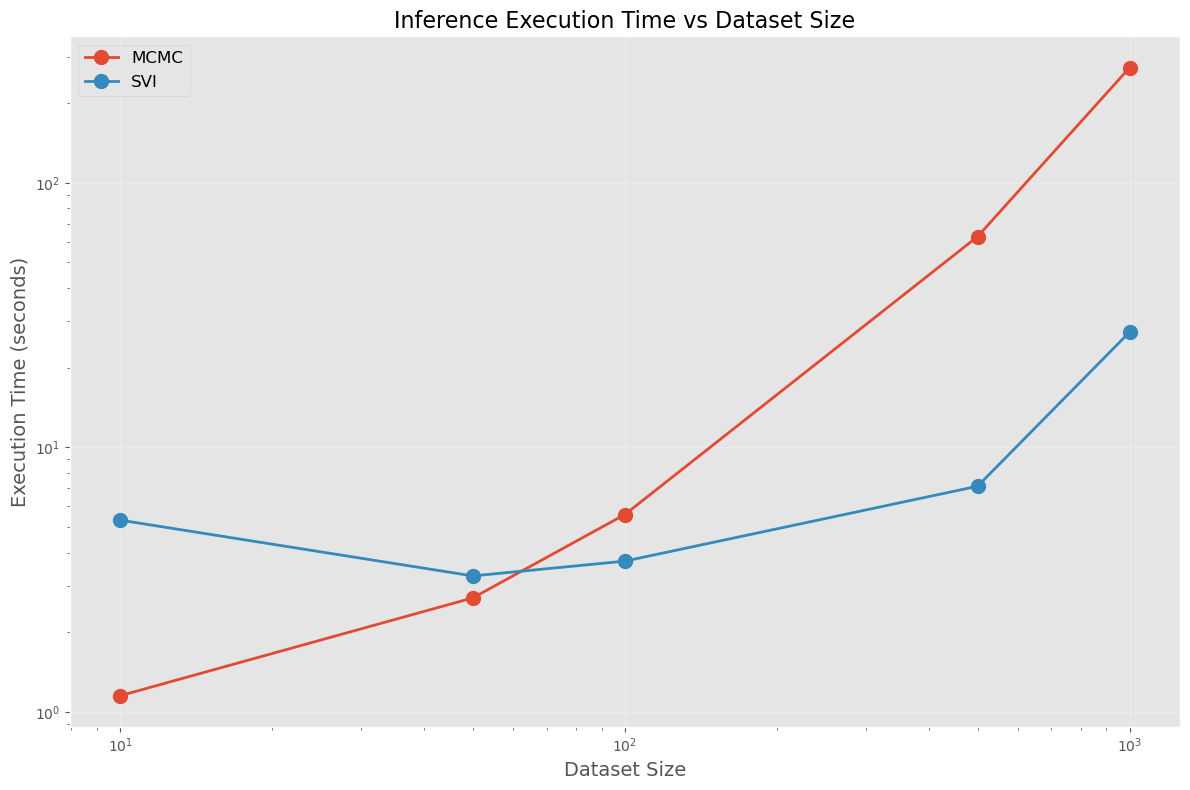

In [8]:
# Plot execution time vs dataset size
plt.figure(figsize=(12, 8))
plt.plot(results_df['dataset_size'], results_df['mcmc_time'], 'o-', label='MCMC', linewidth=2, markersize=10)
plt.plot(results_df['dataset_size'], results_df['svi_time'], 'o-', label='SVI', linewidth=2, markersize=10)
plt.xlabel('Dataset Size', fontsize=14)
plt.ylabel('Execution Time (seconds)', fontsize=14)
plt.title('Inference Execution Time vs Dataset Size', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.xscale('log')
plt.yscale('log')
plt.show()

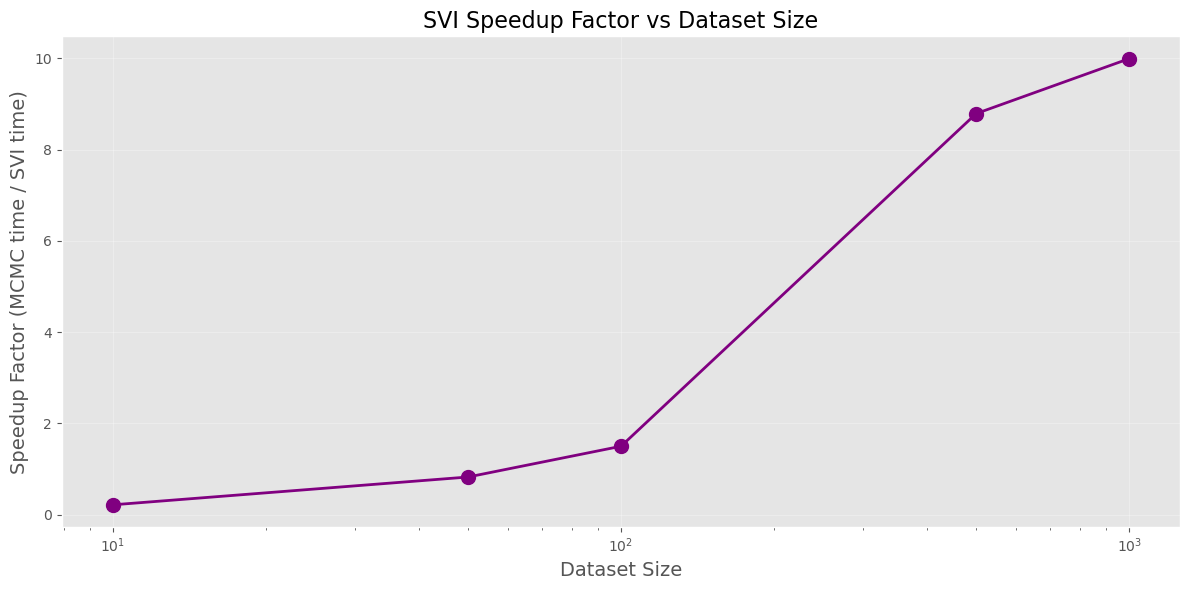

In [9]:
# Plot speedup vs dataset size
plt.figure(figsize=(12, 6))
plt.plot(results_df['dataset_size'], results_df['speedup'], 'o-', linewidth=2, markersize=10, color='purple')
plt.xlabel('Dataset Size', fontsize=14)
plt.ylabel('Speedup Factor (MCMC time / SVI time)', fontsize=14)
plt.title('SVI Speedup Factor vs Dataset Size', fontsize=16)
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.tight_layout()
plt.show()

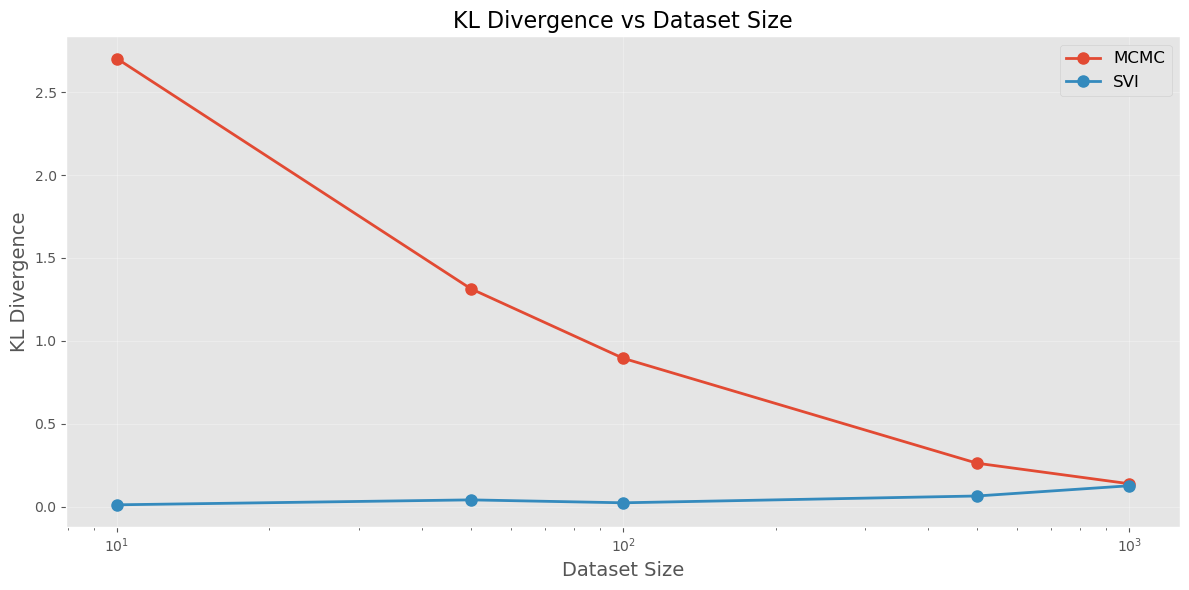

In [10]:
# Plot KL divergence vs dataset size
plt.figure(figsize=(12, 6))
plt.plot(results_df['dataset_size'], results_df['mcmc_kl'], 'o-', label='MCMC', linewidth=2, markersize=8)
plt.plot(results_df['dataset_size'], results_df['svi_kl'], 'o-', label='SVI', linewidth=2, markersize=8)
plt.xlabel('Dataset Size', fontsize=14)
plt.ylabel('KL Divergence', fontsize=14)
plt.title('KL Divergence vs Dataset Size', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.xscale('log')
plt.tight_layout()
plt.show()